# Predicting Late Delivery Risk in a Global Supply Chain

**Data Mining Course Project**

## Problem statement

The goal is to predict whether a non-cancelled order is likely to be delivered late. A supply-chain team could use this prediction at order placement to identify risky orders early and take action before delivery.

This is a **binary classification** problem:

- `Late_delivery_risk = 1`: late delivery
- `Late_delivery_risk = 0`: not late delivery


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 1. Load the data

Upload the CSV file to the folder shown below in Google Drive. Change only `file_path` if your folder or file name is different.


In [33]:
from google.colab import drive

drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/Datamining data/DataCoSupplyChainDataset.csv"

data = pd.read_csv(file_path, encoding="latin1")

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 180519
Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. Initial data understanding


In [34]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [35]:
quality_check = pd.DataFrame({
    "Check": [
        "Exact duplicate rows",
        "Columns containing missing values",
        "Total missing cells"
    ],
    "Result": [
        data.duplicated().sum(),
        data.isna().any().sum(),
        data.isna().sum().sum()
    ]
})

quality_check


,Check,Result
0,Exact duplicate rows,0
1,Columns containing missing values,4
2,Total missing cells,336209


In [36]:
missing_values = (
    data.isna()
    .mean()
    .mul(100)
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .round(3)
    .to_frame("Missing %")
)

missing_values


,Missing %
Product Description,100.000
Order Zipcode,86.240
Customer Lname,0.004
Customer Zipcode,0.002


In [37]:
blank_strings = []

for column in data.select_dtypes(include="object"):
    if (data[column].str.strip() == "").any():
        blank_strings.append(column)

print("Text columns containing blank strings:", blank_strings)


Text columns containing blank strings: []


In [38]:
columns_to_review = [
    "Shipping Mode",
    "Delivery Status",
    "Order Status",
    "Market",
    "Customer Segment"
]

for column in columns_to_review:
    print(f"{column}: {sorted(data[column].dropna().unique())}")


Shipping Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Delivery Status: ['Advance shipping', 'Late delivery', 'Shipping canceled', 'Shipping on time']
Order Status: ['CANCELED', 'CLOSED', 'COMPLETE', 'ON_HOLD', 'PAYMENT_REVIEW', 'PENDING', 'PENDING_PAYMENT', 'PROCESSING', 'SUSPECTED_FRAUD']
Market: ['Africa', 'Europe', 'LATAM', 'Pacific Asia', 'USCA']
Customer Segment: ['Consumer', 'Corporate', 'Home Office']


## 3. Data cleaning

The following columns are removed because they are completely or mostly missing, contain personal information, or are not useful for tabular analysis. `Product Status` is removed later because it has one constant value.


In [39]:
print("Product Status values:")
print(data["Product Status"].value_counts())

print("\nBenefit per order equals Order Profit Per Order:")
print(data["Benefit per order"].equals(data["Order Profit Per Order"]))


Product Status values:
Product Status
0    180519
Name: count, dtype: int64

Benefit per order equals Order Profit Per Order:
True


In [40]:
columns_to_drop = [
    "Product Description",
    "Order Zipcode",
    "Customer Email",
    "Customer Password",
    "Customer Street",
    "Customer Fname",
    "Customer Lname",
    "Product Image",
    "Customer Zipcode",
    "Product Status",
    "Order Profit Per Order"
]

data = data.drop(columns=columns_to_drop)

print("Shape after cleaning:", data.shape)
print("Missing values after cleaning:", data.isna().sum().sum())


Shape after cleaning: (180519, 42)
Missing values after cleaning: 0


In [41]:
date_columns = [
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

for column in date_columns:
    data[column] = pd.to_datetime(
        data[column],
        format="%m/%d/%Y %H:%M",
        errors="raise"
    )

data[date_columns].head()


,order date (DateOrders),shipping date (DateOrders)
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00


## 4. Exploratory data analysis

These charts describe the original product-line data before modelling. They help us understand the business context and select meaningful features.


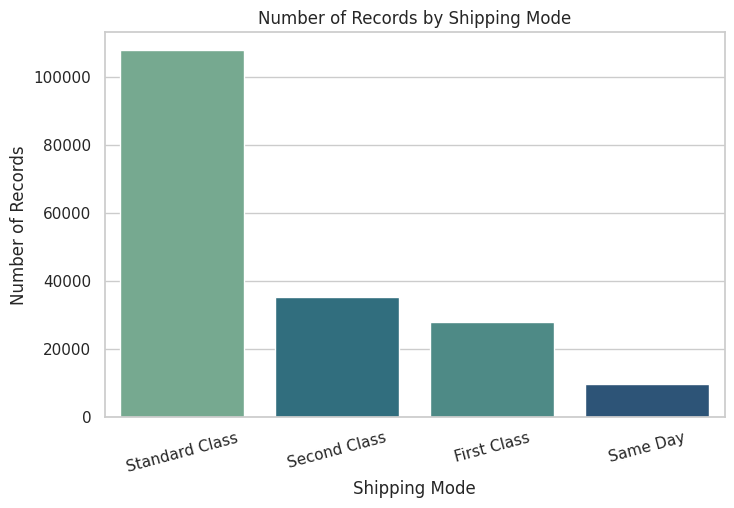

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Shipping Mode",
    order=data["Shipping Mode"].value_counts().index,
    palette="crest",
    hue="Shipping Mode",
    legend=False
)

plt.title("Number of Records by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)
plt.show()


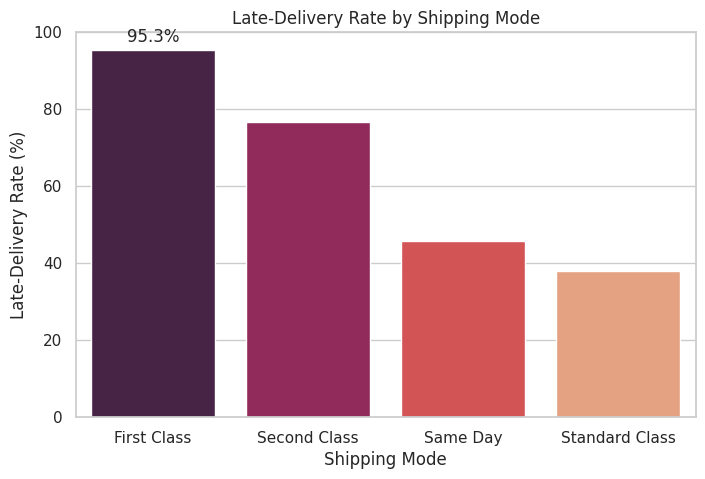

In [43]:
late_rate_by_mode = (
    data.groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Late Delivery Rate (%)")
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=late_rate_by_mode,
    x="Shipping Mode",
    y="Late Delivery Rate (%)",
    palette="rocket",
    hue="Shipping Mode",
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.title("Late-Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late-Delivery Rate (%)")
plt.ylim(0, 100)
plt.show()


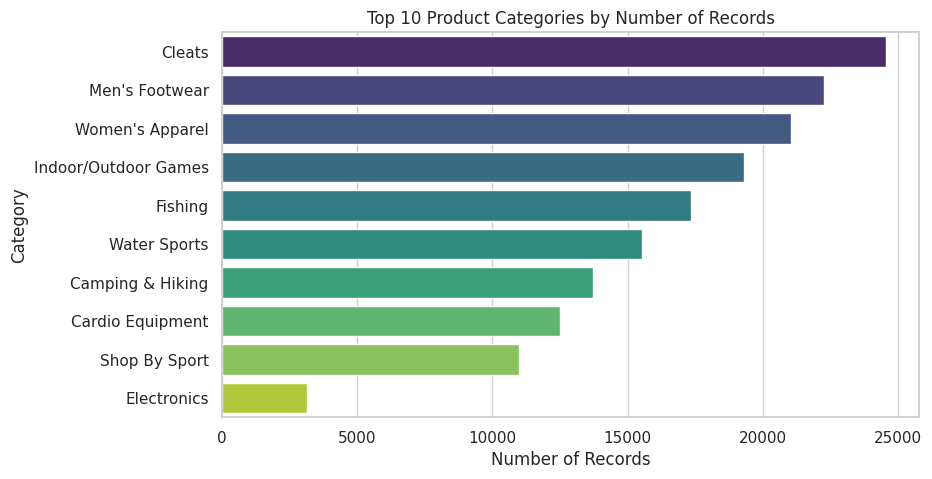

In [44]:
top_categories = data["Category Name"].value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette="viridis",
    hue=top_categories.index,
    legend=False
)

plt.title("Top 10 Product Categories by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Category")
plt.show()


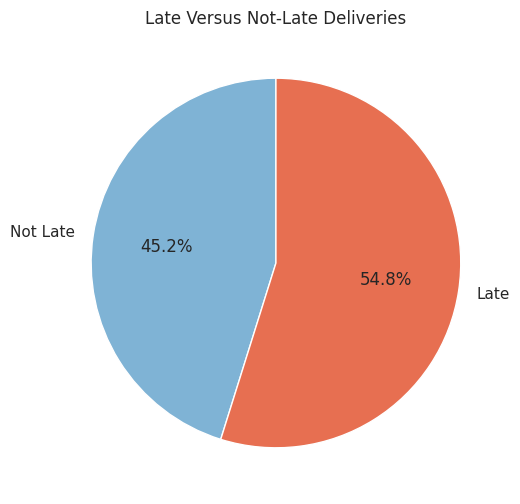

In [45]:
late_counts = data["Late_delivery_risk"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    late_counts,
    labels=["Not Late", "Late"],
    autopct="%.1f%%",
    startangle=90,
    colors=["#7FB3D5", "#E76F51"]
)

plt.title("Late Versus Not-Late Deliveries")
plt.show()


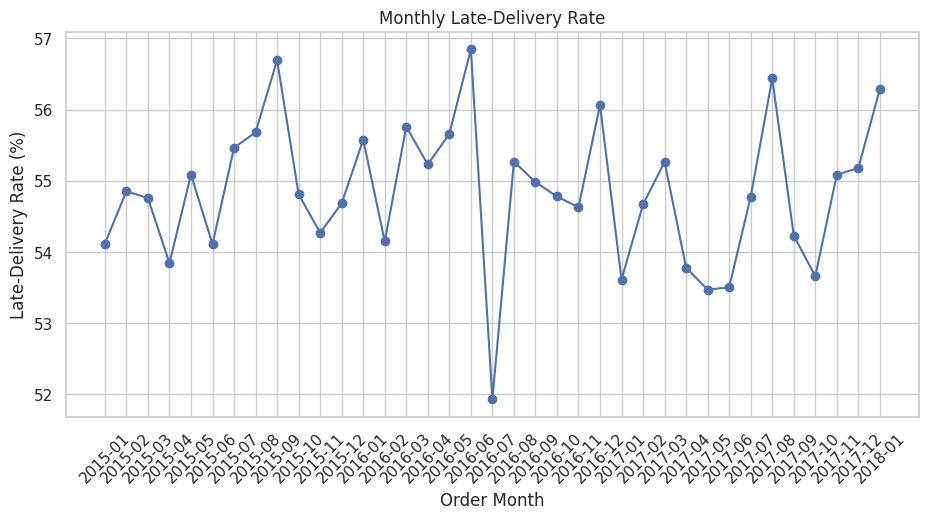

In [46]:
data["Order Month"] = data["order date (DateOrders)"].dt.to_period("M")

monthly_late_rate = (
    data.groupby("Order Month")["Late_delivery_risk"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(11, 5))
plt.plot(monthly_late_rate.index.astype(str), monthly_late_rate.values, marker="o")
plt.title("Monthly Late-Delivery Rate")
plt.xlabel("Order Month")
plt.ylabel("Late-Delivery Rate (%)")
plt.xticks(rotation=45)
plt.show()


### Numerical distributions, skewness, and outliers


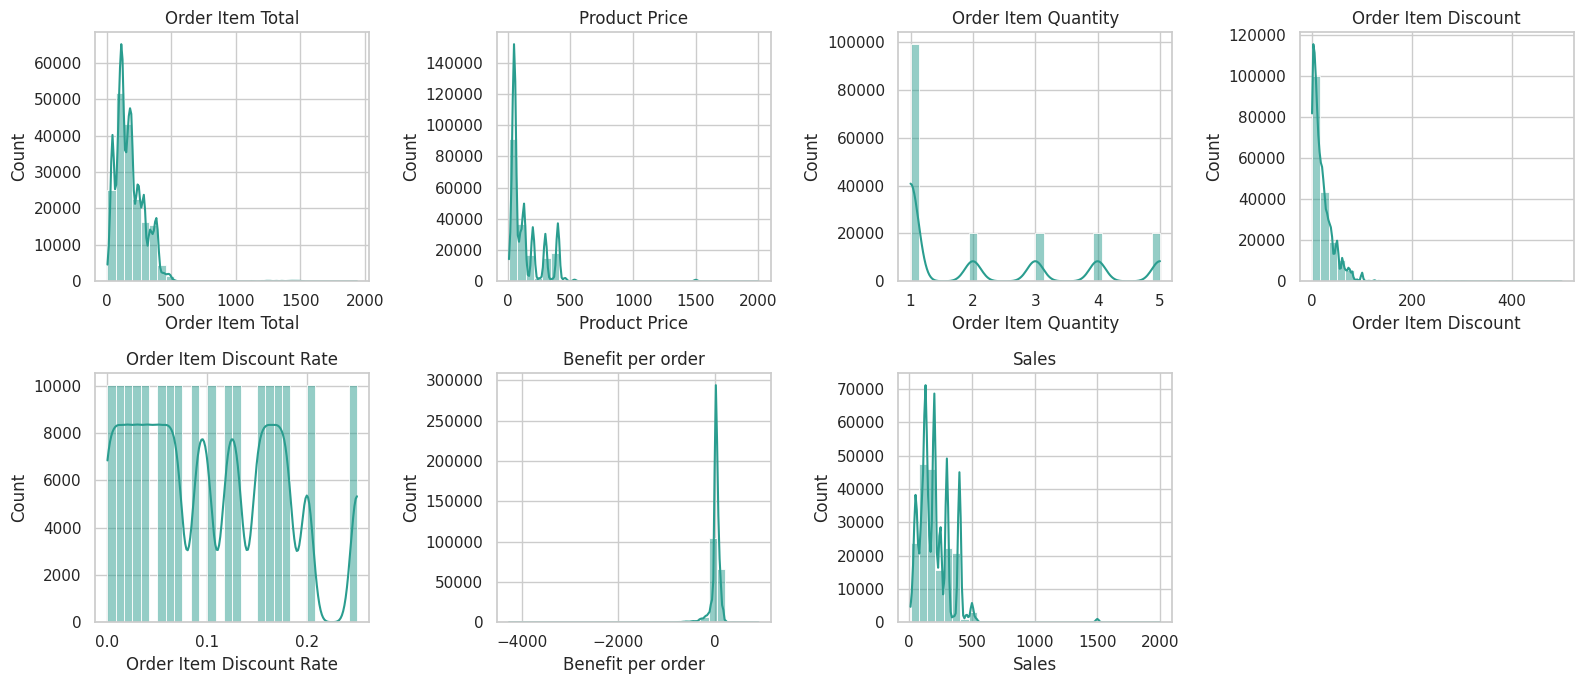

In [47]:
histogram_columns = [
    "Order Item Total",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Benefit per order",
    "Sales"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, column in zip(axes, histogram_columns):
    sns.histplot(data=data, x=column, bins=30, kde=True, ax=ax, color="#2A9D8F")
    ax.set_title(column)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


In [48]:
skew_columns = [
    "Order Item Total",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Profit Ratio",
    "Order Profit Per Order",
    "Benefit per order"
]

skew_columns = [column for column in skew_columns if column in data.columns]

skewness_table = (
    data[skew_columns]
    .skew()
    .sort_values(ascending=False)
    .round(3)
    .to_frame("Skewness")
)

skewness_table


,Skewness
Product Price,3.191
Order Item Discount,3.040
Order Item Total,2.888
Order Item Quantity,0.880
Order Item Discount Rate,0.341
Order Item Profit Ratio,-2.894
Benefit per order,-4.742


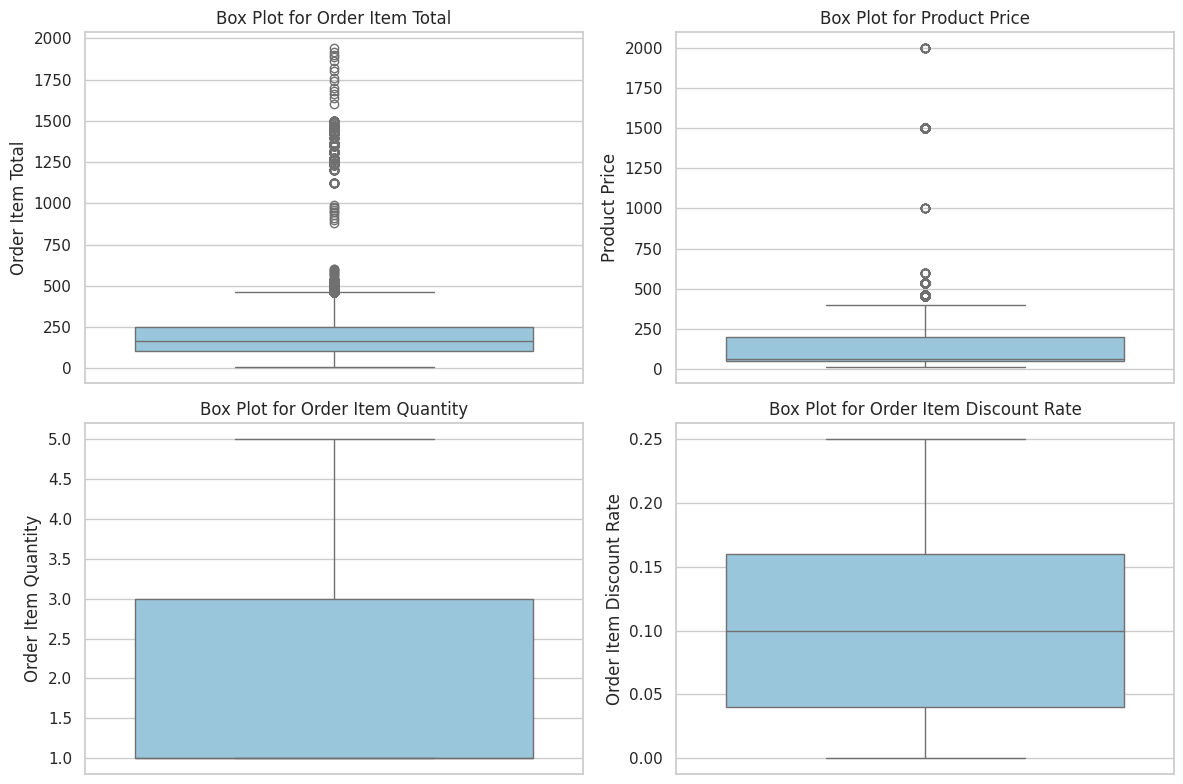

In [49]:
boxplot_columns = [
    "Order Item Total",
    "Product Price",
    "Order Item Quantity",
    "Order Item Discount Rate"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), boxplot_columns):
    sns.boxplot(data=data, y=column, ax=ax, color="#8ECAE6")
    ax.set_title(f"Box Plot for {column}")

plt.tight_layout()
plt.show()


**Outlier decision:** The box plots identify unusual values using the IQR rule. High order totals, product prices, and discounts can be valid business transactions, so no values are removed or changed automatically.

**Skewness decision:** Several financial variables are skewed, which is normal in order data. Numeric features are standardized inside the modelling pipeline. Tree-based models can still work well with skewed numerical inputs.


## 5. Modelling preparation and leakage prevention

The prediction is made at the time an order is placed. The model must not use information that is known only after shipping or delivery. Therefore, these columns are excluded from model features:

- `Delivery Status`
- `Days for shipping (real)`
- `shipping date (DateOrders)`
- `Order Status`
- ID columns

`Days for shipment (scheduled)` is also excluded because it is completely determined by `Shipping Mode` in this dataset.


In [50]:
model_data = data[data["Delivery Status"] != "Shipping canceled"].copy()

target_check = model_data.groupby("Order Id")["Late_delivery_risk"].nunique()

assert (target_check == 1).all(), "Some orders have conflicting target values."

print("Non-cancelled product-line rows:", len(model_data))
print("Orders with conflicting target values:", (target_check > 1).sum())


Non-cancelled product-line rows: 172765
Orders with conflicting target values: 0


### Order-level aggregation

The raw dataset has multiple rows for many orders. Since late delivery is an order-level outcome, the product-line records are aggregated to one row per `Order Id`.


In [51]:
order_data = model_data.groupby("Order Id").agg(
    Late_delivery_risk=("Late_delivery_risk", "first"),
    order_date=("order date (DateOrders)", "first"),
    Shipping_Mode=("Shipping Mode", "first"),
    Market=("Market", "first"),
    Order_Region=("Order Region", "first"),
    Customer_Segment=("Customer Segment", "first"),
    Number_of_Items=("Order Item Id", "count"),
    Total_Quantity=("Order Item Quantity", "sum"),
    Total_Order_Value=("Order Item Total", "sum"),
    Total_Discount=("Order Item Discount", "sum"),
    Average_Product_Price=("Product Price", "mean"),
    Number_of_Products=("Product Card Id", "nunique"),
    Number_of_Categories=("Category Name", "nunique")
).reset_index()

print("Rows before aggregation:", len(model_data))
print("Orders after aggregation:", len(order_data))

order_data.head()


Rows before aggregation: 172765
Orders after aggregation: 62897


,Order Id,Late_delivery_risk,order_date,Shipping_Mode,Market,Order_Region,Customer_Segment,Number_of_Items,Total_Quantity,Total_Order_Value,Total_Discount,Average_Product_Price,Number_of_Products,Number_of_Categories
0,1,0,2015-01-01 00:00:00,Standard Class,LATAM,Central America,Consumer,1,1,239.979996,60.000000,299.980011,1,1
1,2,0,2015-01-01 00:21:00,Standard Class,LATAM,South America,Consumer,3,7,529.380005,50.600000,126.660004,3,3
2,4,1,2015-01-01 01:03:00,Standard Class,LATAM,South America,Home Office,4,14,620.870014,78.980000,46.240000,4,4
3,5,1,2015-01-01 01:24:00,Standard Class,LATAM,South America,Consumer,5,10,987.070007,142.789999,167.984006,4,4
4,7,1,2015-01-01 02:06:00,Second Class,LATAM,South America,Consumer,3,7,525.520004,54.400000,171.986672,3,3


In [52]:
order_data["Order_Month"] = order_data["order_date"].dt.month
order_data["Order_Weekday"] = order_data["order_date"].dt.dayofweek
order_data["Order_Hour"] = order_data["order_date"].dt.hour

order_data.head()


,Order Id,Late_delivery_risk,order_date,Shipping_Mode,Market,Order_Region,Customer_Segment,Number_of_Items,Total_Quantity,Total_Order_Value,Total_Discount,Average_Product_Price,Number_of_Products,Number_of_Categories,Order_Month,Order_Weekday,Order_Hour
0,1,0,2015-01-01 00:00:00,Standard Class,LATAM,Central America,Consumer,1,1,239.979996,60.000000,299.980011,1,1,1,3,0
1,2,0,2015-01-01 00:21:00,Standard Class,LATAM,South America,Consumer,3,7,529.380005,50.600000,126.660004,3,3,1,3,0
2,4,1,2015-01-01 01:03:00,Standard Class,LATAM,South America,Home Office,4,14,620.870014,78.980000,46.240000,4,4,1,3,1
3,5,1,2015-01-01 01:24:00,Standard Class,LATAM,South America,Consumer,5,10,987.070007,142.789999,167.984006,4,4,1,3,1
4,7,1,2015-01-01 02:06:00,Second Class,LATAM,South America,Consumer,3,7,525.520004,54.400000,171.986672,3,3,1,3,2


### Feature experiments

During development, I tested safe extra features such as payment type, order country, number of departments, average item discount rate, order discount rate, value per unit, items per product, and a weekend flag. They did not improve the chronological validation result, so they are not included in the final model. Keeping the original 14 operational features makes the final model simpler and more reliable.


## 6. Chronological train-validation-test split

The orders are sorted from oldest to newest. The first 64% train candidate models, the next 16% select the model and features, and the newest 20% are reserved for one final evaluation. The final test period is never used to make modelling choices.


In [53]:
order_data = order_data.sort_values("order_date").reset_index(drop=True)

test_start = int(len(order_data) * 0.80)
development_data = order_data.iloc[:test_start].copy()
test_data = order_data.iloc[test_start:].copy()

validation_start = int(len(development_data) * 0.80)
train_data = development_data.iloc[:validation_start].copy()
validation_data = development_data.iloc[validation_start:].copy()

split_summary = pd.DataFrame({
    "Period": ["Training", "Validation", "Final test"],
    "Orders": [len(train_data), len(validation_data), len(test_data)],
    "Share": ["64%", "16%", "20%"],
    "Date range": [
        f"{train_data['order_date'].min()} to {train_data['order_date'].max()}",
        f"{validation_data['order_date'].min()} to {validation_data['order_date'].max()}",
        f"{test_data['order_date'].min()} to {test_data['order_date'].max()}"
    ]
})

split_summary


,Period,Orders,Share,Date range
0,Training,40253,64%,2015-01-01 00:00:00 to 2017-01-06 16:29:00
1,Validation,10064,16%,2017-01-06 16:50:00 to 2017-07-10 00:17:00
2,Final test,12580,20%,2017-07-10 00:38:00 to 2018-01-31 23:38:00


## 7. Feature selection and preprocessing


In [54]:
target = "Late_delivery_risk"

categorical_features = [
    "Shipping_Mode",
    "Market",
    "Order_Region",
    "Customer_Segment"
]

numeric_features = [
    "Number_of_Items",
    "Total_Quantity",
    "Total_Order_Value",
    "Total_Discount",
    "Average_Product_Price",
    "Number_of_Products",
    "Number_of_Categories",
    "Order_Month",
    "Order_Weekday",
    "Order_Hour"
]

feature_columns = categorical_features + numeric_features

print("Number of final features before one-hot encoding:", len(feature_columns))


Number of final features before one-hot encoding: 14


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def make_preprocessor(dense=False):
    return ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_features),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=not dense
                ),
                categorical_features
            )
        ]
    )

def make_pipeline(model, dense=False):
    return Pipeline([
        ("preprocessor", make_preprocessor(dense=dense)),
        ("model", model)
    ])


## 8. Model selection on the validation period

Logistic Regression is an interpretable baseline. Decision Tree can learn simple non-linear rules. Random Forest, Extra Trees, and Gradient Boosting are ensemble tree models that can capture more complex patterns. Only the validation period is used here to choose the final model.


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

candidate_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000), False),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        False
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ),
        False
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=2,
            min_samples_leaf=20,
            random_state=42
        ),
        True
    )
]


In [57]:
X_train = train_data[feature_columns]
y_train = train_data[target]
X_validation = validation_data[feature_columns]
y_validation = validation_data[target]

validation_results = []

for name, model, dense in candidate_models:
    pipeline = make_pipeline(model, dense=dense)
    pipeline.fit(X_train, y_train)

    prediction = pipeline.predict(X_validation)
    probability = pipeline.predict_proba(X_validation)[:, 1]

    validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_validation, prediction),
        "Precision": precision_score(y_validation, prediction),
        "Recall": recall_score(y_validation, prediction),
        "F1-score": f1_score(y_validation, prediction),
        "ROC-AUC": roc_auc_score(y_validation, probability)
    })

validation_results = (
    pd.DataFrame(validation_results)
    .sort_values(["Accuracy", "F1-score", "ROC-AUC"], ascending=False)
    .round(3)
)

validation_results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,Random Forest,0.723,0.891,0.584,0.705,0.770
3,Gradient Boosting,0.722,0.892,0.583,0.705,0.770
1,Decision Tree,0.715,0.855,0.600,0.705,0.770
0,Logistic Regression,0.703,0.885,0.550,0.678,0.746


## 9. Final test evaluation

Now the selected approach is trained on the first 80% of orders (training plus validation) and evaluated once on the newest 20% of orders. The final test data has not been used to choose features, parameters, or the probability threshold.


In [58]:
final_train_data = pd.concat([train_data, validation_data])

X_final_train = final_train_data[feature_columns]
y_final_train = final_train_data[target]
X_test = test_data[feature_columns]
y_test = test_data[target]

report_models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000), False),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        False
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ),
        False
    )
]

final_results = []
final_pipelines = {}
final_probabilities = {}

for name, model, dense in report_models:
    pipeline = make_pipeline(model, dense=dense)
    pipeline.fit(X_final_train, y_final_train)

    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)[:, 1]

    final_pipelines[name] = pipeline
    final_probabilities[name] = probability

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1-score": f1_score(y_test, prediction),
        "ROC-AUC": roc_auc_score(y_test, probability)
    })

final_results = pd.DataFrame(final_results).round(3)
final_results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.704,0.856,0.583,0.693,0.749
1,Decision Tree,0.715,0.832,0.632,0.718,0.775
2,Random Forest,0.723,0.876,0.603,0.714,0.776


In [59]:
random_forest_model = final_pipelines["Random Forest"]
y_pred_forest = random_forest_model.predict(X_test)
y_prob_forest = final_probabilities["Random Forest"]

print(classification_report(y_test, y_pred_forest, target_names=["Not Late", "Late"]))


              precision    recall  f1-score   support

    Not Late       0.62      0.88      0.73      5353
        Late       0.88      0.60      0.71      7227

    accuracy                           0.72     12580
   macro avg       0.75      0.74      0.72     12580
weighted avg       0.77      0.72      0.72     12580



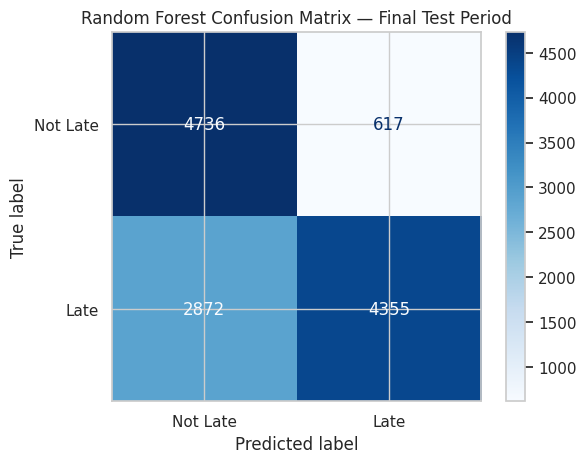

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    display_labels=["Not Late", "Late"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix — Final Test Period")
plt.show()


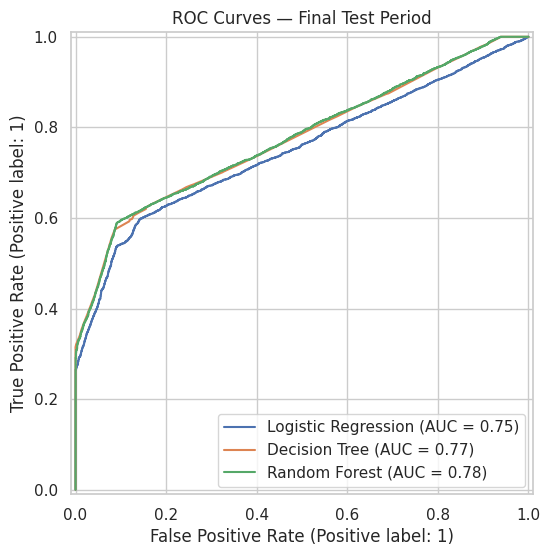

In [61]:
plt.figure(figsize=(8, 6))
ax = plt.gca()

for name, probability in final_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probability,
        name=name,
        ax=ax
    )

plt.title("ROC Curves — Final Test Period")
plt.show()


In [62]:
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
random_forest_accuracy = final_results.loc[
    final_results["Model"] == "Random Forest", "Accuracy"
].iloc[0]

print("Simple majority-class baseline accuracy:", round(baseline_accuracy, 3))
print("Random Forest final accuracy:", random_forest_accuracy)


Simple majority-class baseline accuracy: 0.574
Random Forest final accuracy: 0.723


## 10. Conclusion

This project predicts whether a non-cancelled supply-chain order is likely to be delivered late. The final Random Forest model is selected using a chronological validation period and then evaluated once on a later, untouched test period. Its result should be interpreted together with precision, recall, F1-score, and ROC-AUC—not accuracy alone.

The model uses only information available at order placement, so it avoids data leakage from post-delivery outcomes. Its predictions could help a logistics team prioritize orders that need attention.


